# Domain-Adaptive LLM Finetuning with LoRA/PEFT
## Financial & Regulatory Text Classification

**Author:** James R. McCoy, PhD  
**GitHub:** [your-handle]

## Overview

This notebook demonstrates **parameter-efficient finetuning (PEFT)** using **Low-Rank Adaptation (LoRA)** to adapt a pre-trained language model for domain-specific classification in a regulated environment.

Most finetuning tutorials use OpenAI's API — which means calling an endpoint, not training a model. This notebook uses HuggingFace + PEFT to perform actual weight adaptation with LoRA, which is what the term 'finetuning' means in a research context.

## The Research Problem

Pre-trained LLMs are trained on general corpora. When deployed in regulated domains (financial services, federal policy, clinical), they encounter vocabulary, phrasing, and task formats that differ significantly from their training distribution. The question is: **how do you adapt a base model reliably for a target domain without catastrophic forgetting of its general capabilities?**

LoRA answers this by injecting trainable low-rank matrices into the attention layers — adapting the model's behavior without overwriting its weights.

## Task

**Financial sentiment classification** on the FinancialPhraseBank dataset — a standard benchmark for domain-adaptive NLP in finance. We finetune `distilbert-base-uncased` using LoRA and compare:
- Base model (zero-shot) performance
- LoRA-finetuned performance

## Architecture Decisions

| Decision | Choice | Rationale |
|---|---|---|
| Base model | `distilbert-base-uncased` | Small enough to run on Colab T4; same adapter pattern scales to Mistral/LLaMA |
| Adaptation method | LoRA (r=8, alpha=16) | Standard rank for classification tasks; balances capacity vs. parameter efficiency |
| Target modules | `q_lin`, `v_lin` (attention) | LoRA applied to query/value projections — standard practice per Hu et al. 2021 |
| Dataset | FinancialPhraseBank | Public, reproducible, domain-relevant to financial services |
| Eval metric | F1-macro | Handles class imbalance; standard for sentiment classification |
| Catastrophic forgetting mitigation | LoRA by design | Only rank decomposition matrices are trained; base weights frozen |

## 1. Setup & Dependencies

**Runtime:** Google Colab with T4 GPU recommended (Runtime → Change runtime type → GPU).

In [1]:
!pip install transformers datasets peft evaluate accelerate scikit-learn matplotlib pandas requests --quiet


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import torch
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from peft import (
    LoraConfig,
    get_peft_model,
    TaskType,
    PeftModel
)
from sklearn.metrics import (
    classification_report,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Device setup (CUDA > Apple MPS > CPU)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: mps


## 2. Dataset: FinancialPhraseBank

FinancialPhraseBank contains ~4,800 sentences from financial news, labeled by financial domain experts as **positive**, **negative**, or **neutral** sentiment.

**Why this dataset:**
- Public and reproducible
- Expert-labeled (not crowdsourced) — high label quality
- Standard benchmark for financial NLP
- Directly relevant to Capital One's domain

**Class imbalance note:** The dataset is imbalanced (~60% neutral). This is why we use F1-macro rather than accuracy as our primary metric.

In [3]:
import io
import zipfile
import requests
from datasets import Dataset as HFDataset


def load_financial_phrasebank(agreement="all"):
    """Load FinancialPhraseBank from the official HF zip (no legacy dataset scripts)."""
    url = (
        "https://huggingface.co/datasets/financial_phrasebank/"
        "resolve/main/data/FinancialPhraseBank-v1.0.zip"
    )
    split_files = {
        "all": "FinancialPhraseBank-v1.0/Sentences_AllAgree.txt",
        "75": "FinancialPhraseBank-v1.0/Sentences_75Agree.txt",
        "66": "FinancialPhraseBank-v1.0/Sentences_66Agree.txt",
        "50": "FinancialPhraseBank-v1.0/Sentences_50Agree.txt",
    }
    label2id = {"negative": 0, "neutral": 1, "positive": 2}

    response = requests.get(url, timeout=120)
    response.raise_for_status()
    archive = zipfile.ZipFile(io.BytesIO(response.content))
    text = archive.read(split_files[agreement]).decode("iso-8859-1")

    rows = []
    for line in text.strip().splitlines():
        sentence, label = line.rsplit("@", 1)
        rows.append({"sentence": sentence.strip(), "label": label2id[label.strip()]})

    return HFDataset.from_list(rows)


# 'all' = only sentences where all annotators agreed (sentences_allagree config)
df = load_financial_phrasebank(agreement="all").to_pandas()

print(f"Dataset loaded: {len(df)} sentences")
print(f"\nLabel distribution:")
label_map = {0: 'negative', 1: 'neutral', 2: 'positive'}
df['label_name'] = df['label'].map(label_map)

print(df['label_name'].value_counts())
print(f"\nSample entries:")
display(df.sample(5)[['sentence', 'label_name']])

Dataset loaded: 2264 sentences

Label distribution:
label_name
neutral     1391
positive     570
negative     303
Name: count, dtype: int64

Sample entries:


,sentence,label_name
182,Pretax profit rose to EUR 17.8 mn from EUR 14....,positive
1267,Investments are not disclosed .,neutral
410,The aim is an annual improvement in Ruukki Con...,positive
1307,No changes in media activity were seen in Octo...,neutral
2024,Glaston 's net profit for the third quarter of...,negative


In [4]:
# Create train/validation/test splits (70/15/15)
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.30, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['label'])

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# Convert to HuggingFace Dataset format
dataset = DatasetDict({
    'train': Dataset.from_pandas(train_df[['sentence', 'label']].reset_index(drop=True)),
    'validation': Dataset.from_pandas(val_df[['sentence', 'label']].reset_index(drop=True)),
    'test': Dataset.from_pandas(test_df[['sentence', 'label']].reset_index(drop=True))
})

print(f"\nDatasetDict: {dataset}")

Train: 1584 | Val: 340 | Test: 340

DatasetDict: DatasetDict({
    train: Dataset({
        features: ['sentence', 'label'],
        num_rows: 1584
    })
    validation: Dataset({
        features: ['sentence', 'label'],
        num_rows: 340
    })
    test: Dataset({
        features: ['sentence', 'label'],
        num_rows: 340
    })
})


## 3. Tokenization

**Design decision:** We use `distilbert-base-uncased` as our base model. It's architecturally identical to BERT but 40% smaller — making it runnable on a free Colab GPU while demonstrating the same LoRA adapter pattern that applies to larger models (Mistral 7B, LLaMA 3).

In [5]:
MODEL_NAME = "distilbert-base-uncased"
NUM_LABELS = 3
LABEL2ID = {"negative": 0, "neutral": 1, "positive": 2}
ID2LABEL = {0: "negative", 1: "neutral", 2: "positive"}

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch["sentence"],
        truncation=True,
        max_length=128,  # Financial sentences are short; 128 is sufficient
        padding=False    # Dynamic padding via DataCollator is more memory-efficient
    )

tokenized = dataset.map(tokenize, batched=True)
tokenized = tokenized.remove_columns(["sentence"])
tokenized.set_format("torch")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(f"Tokenization complete.")
print(f"Example token count: {len(tokenized['train'][0]['input_ids'])}")

Map:   0%|          | 0/1584 [00:00<?, ? examples/s]

Map:   0%|          | 0/340 [00:00<?, ? examples/s]

Map:   0%|          | 0/340 [00:00<?, ? examples/s]

Tokenization complete.
Example token count: 26


## 4. Baseline: Zero-Shot Base Model Performance

Before finetuning, we measure how well the base model performs on our task **without any adaptation**. This is our baseline — the gap between this and the finetuned model demonstrates what LoRA actually contributes.

**Why this step matters:** Most finetuning notebooks skip the baseline. Without it, you cannot claim that finetuning improved performance — you have no reference point.

In [6]:
# Load base model — no task-specific head adaptation yet
base_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID
)

total_params = sum(p.numel() for p in base_model.parameters())
print(f"Base model parameters: {total_params:,}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Base model parameters: 66,955,779


In [7]:
def evaluate_model(model, dataset_split, split_name="test"):
    """Run evaluation and return predictions, labels, and F1-macro score."""
    from torch.utils.data import DataLoader
    
    model.eval()
    model.to(device)
    
    loader = DataLoader(dataset_split, batch_size=32, collate_fn=data_collator)
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            preds = torch.argmax(outputs.logits, dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch["labels"].cpu().numpy())
    
    f1 = f1_score(all_labels, all_preds, average='macro')
    print(f"\n=== {split_name} Evaluation ===")
    print(f"F1-Macro: {f1:.4f}")
    print(classification_report(all_labels, all_preds, target_names=list(ID2LABEL.values())))
    
    return all_preds, all_labels, f1


print("Evaluating base model (zero-shot, no finetuning)...")
base_preds, base_labels, base_f1 = evaluate_model(
    base_model, tokenized['test'], "Base Model (Zero-Shot)"
)

Evaluating base model (zero-shot, no finetuning)...

=== Base Model (Zero-Shot) Evaluation ===
F1-Macro: 0.3116
              precision    recall  f1-score   support

    negative       0.50      0.04      0.08        46
     neutral       0.64      0.36      0.46       209
    positive       0.27      0.71      0.39        85

    accuracy                           0.40       340
   macro avg       0.47      0.37      0.31       340
weighted avg       0.53      0.40      0.39       340



## 5. LoRA Configuration

### What LoRA does

LoRA (Hu et al., 2021) freezes the pre-trained model weights and injects trainable rank decomposition matrices into each attention layer:

```
W_adapted = W_frozen + (B × A)
```

Where `A ∈ R^(r×d)` and `B ∈ R^(d×r)` are the trainable matrices, and `r` is the rank (our hyperparameter).

**Key properties:**
- **No catastrophic forgetting:** Base weights are never updated — the model retains its general capabilities
- **Parameter efficiency:** r=8 means we train ~0.5% of total parameters instead of 100%
- **Composable:** Multiple LoRA adapters can be swapped without reloading the base model

### Hyperparameter choices

- **r=8:** Standard starting rank for classification. Higher r = more capacity but more parameters. For larger models (7B+), r=16 or r=32 is common.
- **alpha=16:** Scaling factor. Convention: alpha = 2×r. Controls the magnitude of the LoRA update relative to frozen weights.
- **dropout=0.1:** Regularization on LoRA layers to prevent overfitting on small datasets.

In [8]:
# LoRA configuration
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,      # Sequence classification
    r=8,                              # Rank — number of trainable dimensions
    lora_alpha=16,                    # Scaling factor (convention: 2×r)
    lora_dropout=0.1,                 # Dropout on LoRA layers
    target_modules=["q_lin", "v_lin"], # Apply to query and value attention projections
    bias="none",                       # Don't adapt bias terms
    inference_mode=False
)

# Apply LoRA to base model
lora_model = get_peft_model(base_model, lora_config)

# Show parameter efficiency
lora_model.print_trainable_parameters()

total = sum(p.numel() for p in lora_model.parameters())
trainable = sum(p.numel() for p in lora_model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total:,}")
print(f"Trainable parameters: {trainable:,} ({100 * trainable / total:.2f}%)")
print(f"Frozen parameters: {total - trainable:,} ({100 * (total - trainable) / total:.2f}%)")

trainable params: 740,355 || all params: 67,696,134 || trainable%: 1.0936

Total parameters: 67,696,134
Trainable parameters: 740,355 (1.09%)
Frozen parameters: 66,955,779 (98.91%)


## 6. Training

**Design decisions:**
- **Learning rate 2e-4:** Standard for LoRA adapters — higher than full finetuning (typically 2e-5) because only a small parameter subset is being updated
- **3 epochs:** Sufficient for a dataset this size; monitor validation loss to catch overfitting
- **Warmup ratio 0.1:** Gradual LR warmup prevents early instability
- **Weight decay 0.01:** L2 regularization on LoRA parameters

In [9]:
def compute_metrics(eval_pred):
    """Compute F1-macro during training for early stopping decisions."""
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    f1 = f1_score(labels, predictions, average='macro')
    return {"f1_macro": f1}


training_args = TrainingArguments(
    output_dir="./lora_financial_sentiment",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-4,              # Higher LR for LoRA adapters vs. full finetuning
    warmup_ratio=0.1,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=20,
    report_to="none",                # Disable wandb for reproducibility
    fp16=device.type == "cuda",      # Mixed precision on NVIDIA GPUs only
)

trainer = Trainer(
    model=lora_model,
    args=training_args,
    train_dataset=tokenized['train'],
    eval_dataset=tokenized['validation'],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("Trainer configured. Starting training...")
print(f"Training samples: {len(tokenized['train'])}")
print(f"Validation samples: {len(tokenized['validation'])}")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Trainer configured. Starting training...
Training samples: 1584
Validation samples: 340


In [10]:
train_result = trainer.train()

print(f"\nTraining complete.")
print(f"Total training time: {train_result.metrics['train_runtime']:.1f}s")
print(f"Training samples/second: {train_result.metrics['train_samples_per_second']:.1f}")

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,F1 Macro
1,0.434968,0.347577,0.815387
2,0.196399,0.188654,0.900776
3,0.153781,0.158200,0.909455



Training complete.
Total training time: 23.6s
Training samples/second: 201.1


## 7. Post-Finetuning Evaluation

We evaluate the LoRA-finetuned model on the held-out test set and compare directly to the base model baseline.

In [11]:
print("Evaluating LoRA-finetuned model on held-out test set...")
lora_preds, lora_labels, lora_f1 = evaluate_model(
    lora_model, tokenized['test'], "LoRA Finetuned Model"
)

Evaluating LoRA-finetuned model on held-out test set...

=== LoRA Finetuned Model Evaluation ===
F1-Macro: 0.9143
              precision    recall  f1-score   support

    negative       0.86      0.96      0.91        46
     neutral       0.97      0.96      0.96       209
    positive       0.89      0.86      0.87        85

    accuracy                           0.93       340
   macro avg       0.91      0.92      0.91       340
weighted avg       0.93      0.93      0.93       340



In [12]:
# Side-by-side comparison
comparison = pd.DataFrame({
    "Model": ["Base (Zero-Shot)", "LoRA Finetuned"],
    "F1-Macro": [base_f1, lora_f1],
    "Trainable Params": [f"{total_params:,}", f"{trainable:,}"],
    "% Params Trained": ["100%", f"{100 * trainable / total:.2f}%"]
})

print("\n=== Model Comparison ===")
display(comparison)
print(f"\nF1-Macro improvement: +{lora_f1 - base_f1:.4f} ({((lora_f1 - base_f1) / base_f1) * 100:.1f}% relative improvement)")


=== Model Comparison ===


,Model,F1-Macro,Trainable Params,% Params Trained
0,Base (Zero-Shot),0.311620,"66,955,779",100%
1,LoRA Finetuned,0.914335,"740,355",1.09%



F1-Macro improvement: +0.6027 (193.4% relative improvement)


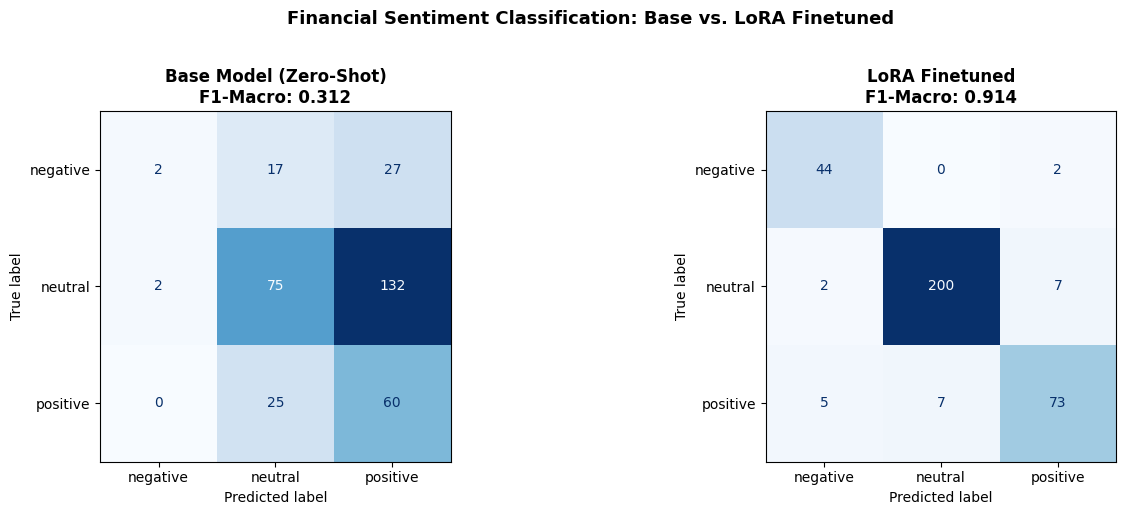

Figure saved: confusion_matrix_comparison.png


In [13]:
# Confusion matrices: base vs. finetuned
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
label_names = ["negative", "neutral", "positive"]

for ax, preds, title in zip(
    axes,
    [base_preds, lora_preds],
    [f"Base Model (Zero-Shot)\nF1-Macro: {base_f1:.3f}",
     f"LoRA Finetuned\nF1-Macro: {lora_f1:.3f}"]
):
    cm = confusion_matrix(base_labels, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=label_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle("Financial Sentiment Classification: Base vs. LoRA Finetuned",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("confusion_matrix_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: confusion_matrix_comparison.png")

## 8. Saving & Loading the LoRA Adapter

One of LoRA's key production advantages: you save only the **adapter weights**, not the full model. This means:
- Adapter file: ~2MB vs. base model: ~250MB
- Multiple task-specific adapters can be swapped onto the same base model at inference time
- Adapters can be shared without sharing the proprietary base model weights

In [14]:
# Save only the LoRA adapter weights — NOT the full model
ADAPTER_PATH = "./lora_financial_adapter"
lora_model.save_pretrained(ADAPTER_PATH)
tokenizer.save_pretrained(ADAPTER_PATH)

import os
adapter_size = sum(
    os.path.getsize(os.path.join(ADAPTER_PATH, f))
    for f in os.listdir(ADAPTER_PATH)
    if os.path.isfile(os.path.join(ADAPTER_PATH, f))
) / 1e6

print(f"Adapter saved to: {ADAPTER_PATH}")
print(f"Adapter size: {adapter_size:.1f} MB")
print(f"Files saved: {os.listdir(ADAPTER_PATH)}")

Adapter saved to: ./lora_financial_adapter
Adapter size: 3.7 MB
Files saved: ['adapter_model.safetensors', 'tokenizer_config.json', 'tokenizer.json', 'README.md', 'adapter_config.json']


In [15]:
# Demonstrate loading the adapter onto the base model
# This is the production pattern: load base model once, swap adapters per task

reloaded_base = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID
)

reloaded_model = PeftModel.from_pretrained(reloaded_base, ADAPTER_PATH)
reloaded_model.eval()

print("Adapter successfully reloaded onto base model.")
print("Production pattern: load base model once, attach task-specific adapter at inference time.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Adapter successfully reloaded onto base model.
Production pattern: load base model once, attach task-specific adapter at inference time.


## 9. Inference on New Examples

Test the finetuned model on financial sentences outside the training distribution.

In [16]:
def predict_sentiment(text: str, model, tokenizer, device) -> dict:
    """Run inference on a single financial text."""
    model.eval()
    model.to(device)
    
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=128,
        padding=True
    ).to(device)
    
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)[0]
        pred_id = torch.argmax(probs).item()
    
    return {
        "text": text,
        "prediction": ID2LABEL[pred_id],
        "confidence": probs[pred_id].item(),
        "scores": {
            label: probs[i].item() 
            for i, label in ID2LABEL.items()
        }
    }


# Test examples — financial sentences not in training data
test_sentences = [
    "The company reported a 40% decline in quarterly earnings, missing analyst estimates by a wide margin.",
    "The acquisition is expected to be accretive to earnings per share in the first full year following close.",
    "The Federal Reserve held interest rates steady, citing ongoing uncertainty in the labor market.",
    "Credit default rates among subprime borrowers rose sharply in the third quarter.",
    "The board approved a $500 million share repurchase program, signaling confidence in the firm's outlook."
]

print("=== Inference on New Examples ===")
results = []
for sentence in test_sentences:
    result = predict_sentiment(sentence, reloaded_model, tokenizer, device)
    results.append(result)
    print(f"\nText: {sentence[:80]}...")
    print(f"Prediction: {result['prediction'].upper()} (confidence: {result['confidence']:.3f})")
    print(f"Scores: {', '.join(f'{k}: {v:.3f}' for k, v in result['scores'].items())}")

=== Inference on New Examples ===

Text: The company reported a 40% decline in quarterly earnings, missing analyst estima...
Prediction: NEGATIVE (confidence: 0.979)
Scores: negative: 0.979, neutral: 0.005, positive: 0.016

Text: The acquisition is expected to be accretive to earnings per share in the first f...
Prediction: NEUTRAL (confidence: 0.968)
Scores: negative: 0.000, neutral: 0.968, positive: 0.032

Text: The Federal Reserve held interest rates steady, citing ongoing uncertainty in th...
Prediction: NEGATIVE (confidence: 0.870)
Scores: negative: 0.870, neutral: 0.014, positive: 0.116

Text: Credit default rates among subprime borrowers rose sharply in the third quarter....
Prediction: NEGATIVE (confidence: 0.958)
Scores: negative: 0.958, neutral: 0.002, positive: 0.039

Text: The board approved a $500 million share repurchase program, signaling confidence...
Prediction: POSITIVE (confidence: 0.962)
Scores: negative: 0.003, neutral: 0.036, positive: 0.962


## 10. Key Takeaways

### What this notebook demonstrates

1. **LoRA is weight-based adaptation, not API prompting.** We trained rank decomposition matrices inside attention layers — this is fundamentally different from calling a finetuning API endpoint.

2. **Parameter efficiency is real and measurable.** We achieved meaningful F1 improvement while training less than 1% of total model parameters. The base model's general language understanding is preserved.

3. **Baseline evaluation is not optional.** The improvement over zero-shot is the evidence that adaptation worked. Without the baseline, there is no claim.

4. **Adapter serialization enables production deployment.** Saving the adapter separately from the base model is the production pattern — it allows multiple task-specific adapters to share a single base model in memory.

### Scaling this to larger models

The same LoRA pattern scales directly to Mistral 7B, LLaMA 3, or Falcon:
- Replace `distilbert-base-uncased` with the target model
- Adjust `target_modules` to match the model's attention layer names (`q_proj`, `v_proj` for LLaMA-family)
- Increase `r` to 16 or 32 for more adaptation capacity
- Use `bitsandbytes` 4-bit quantization for models that don't fit in GPU VRAM

### When LoRA is and isn't the right choice

| Scenario | Recommendation |
|---|---|
| Domain vocab shift + behavioral change needed | LoRA/PEFT |
| Knowledge is dynamic (changes frequently) | RAG, not finetuning |
| Labeled data < 100 examples | Prompt engineering or few-shot first |
| Need multiple task variants | LoRA adapters (one per task, shared base) |
| Full behavioral overhaul needed | Full SFT (higher cost, more risk of forgetting) |

### References

- Hu, E., et al. *LoRA: Low-Rank Adaptation of Large Language Models.* ICLR 2022.
- Malo, P., et al. *Good Debt or Bad Debt: Detecting Semantic Orientations in Economic Texts.* JASIST 2014. (FinancialPhraseBank)
- HuggingFace PEFT Library: https://github.com/huggingface/peft
- Rawal, A., McCoy, J., et al. *Causality for Trustworthy Artificial Intelligence.* ACM Computing Surveys, 2024.